# Monte Carlo & Temporal Difference Learning

## Model-Free Learning

When we **don't know** $P(s'|s,a)$ or $R(s,a)$, we learn directly from experience (episodes/samples).

| Method | Updates | Requires full episode? | Bias | Variance |
|--------|---------|----------------------|------|----------|
| Monte Carlo | After episode | ✅ Yes | Low | High |
| TD(0) | After each step | ❌ No | High | Low |
| TD(λ) | Blends both | ❌ No | Adjustable | Adjustable |

---

## Monte Carlo Methods

**Idea**: Run complete episodes, then update value estimates using actual returns.

$$V(S_t) \leftarrow V(S_t) + \alpha\left[G_t - V(S_t)\right]$$

where $G_t = R_{t+1} + \gamma R_{t+2} + \cdots + \gamma^{T-t-1}R_T$ is the actual return.

### First-Visit vs Every-Visit MC
- **First-visit**: Only update $V(s)$ for the **first** time $s$ is visited in an episode
- **Every-visit**: Update $V(s)$ **every** time $s$ is visited

Both converge to $V^\pi(s)$ as visits $\to \infty$.

### MC Control (with ε-soft policies)
- Maintain $Q(s,a)$ estimates
- After each episode, improve policy greedily
- Keep ε-greedy to maintain exploration

---

## Temporal Difference Learning

**Key insight**: Don't wait for the episode to end. Bootstrap using the current estimate of the next state.

### TD(0) Update

$$V(S_t) \leftarrow V(S_t) + \alpha\underbrace{\left[R_{t+1} + \gamma V(S_{t+1}) - V(S_t)\right]}_{\delta_t \text{ (TD error)}}$$

The **TD error** $\delta_t$ is the difference between:
- **TD target**: $R_{t+1} + \gamma V(S_{t+1})$ (what we observed + bootstrap)
- **Current estimate**: $V(S_t)$

---

## SARSA (On-Policy TD Control)

Updates Q-values using the tuple $(S_t, A_t, R_{t+1}, S_{t+1}, A_{t+1})$ hence **SARSA**:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha\left[R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t)\right]$$

- **On-policy**: learns the value of the policy being followed (ε-greedy)
- Conservative learns to avoid risky paths even when exploring

---

## Q-Learning (Off-Policy TD Control)

Updates Q-values using the **max** over next actions (greedy):

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha\left[R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a') - Q(S_t, A_t)\right]$$

- **Off-policy**: learns the **optimal** Q regardless of the behavior policy
- Directly learns $Q^*$

---

## Expected SARSA

Uses the **expected** value over next actions (instead of sampled or max):

$$Q(S_t,A_t) \leftarrow Q(S_t,A_t) + \alpha\left[R_{t+1} + \gamma \sum_{a'} \pi(a'|S_{t+1}) Q(S_{t+1},a') - Q(S_t,A_t)\right]$$

Lower variance than SARSA, often outperforms Q-Learning.

---

## Double Q-Learning

Q-Learning overestimates action values (maximization bias). Fix: use two Q-networks:

$$Q_1(S,A) \leftarrow Q_1(S,A) + \alpha\left[R + \gamma Q_2(S', \arg\max_{a'}Q_1(S',a')) - Q_1(S,A)\right]$$

Randomly update $Q_1$ or $Q_2$ each step.

---

## n-Step TD

Bridge between MC (full return) and TD(0) (1-step bootstrap):

$$G_t^{(n)} = R_{t+1} + \gamma R_{t+2} + \cdots + \gamma^{n-1}R_{t+n} + \gamma^n V(S_{t+n})$$

$$V(S_t) \leftarrow V(S_t) + \alpha\left[G_t^{(n)} - V(S_t)\right]$$

n=1 is TD(0), n=∞ is MC.

---

## TD(λ) and Eligibility Traces

**Eligibility trace** $e_t(s)$: how recently and frequently was state $s$ visited:

$$e_t(s) = \gamma\lambda e_{t-1}(s) + \mathbf{1}[S_t=s]$$

**TD(λ) update** (backward view):

$$V(s) \leftarrow V(s) + \alpha \delta_t e_t(s) \quad \forall s$$

$\lambda=0$ → TD(0), $\lambda=1$ → MC.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ─── Simple Environment: CliffWalk ───
class CliffWalk:
    """4x12 grid. Bottom row is cliff (fall = -100, back to start)."""
    def __init__(self):
        self.height, self.width = 4, 12
        self.start = (3, 0)
        self.goal  = (3, 11)
        self.cliff  = [(3, c) for c in range(1, 11)]
        self.state  = self.start
        self.actions = [(-1,0),(1,0),(0,-1),(0,1)]  # up,down,left,right

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        r, c = self.state
        dr, dc = self.actions[action]
        nr = max(0, min(self.height-1, r+dr))
        nc = max(0, min(self.width-1, c+dc))
        self.state = (nr, nc)
        if self.state in self.cliff:
            self.state = self.start
            return self.state, -100, False
        if self.state == self.goal:
            return self.state, -1, True
        return self.state, -1, False

    def state_idx(self, s): return s[0]*self.width + s[1]
    @property
    def n_states(self): return self.height * self.width
    @property
    def n_actions(self): return 4

env = CliffWalk()
print(f"CliffWalk: {env.n_states} states, {env.n_actions} actions")

CliffWalk: 48 states, 4 actions


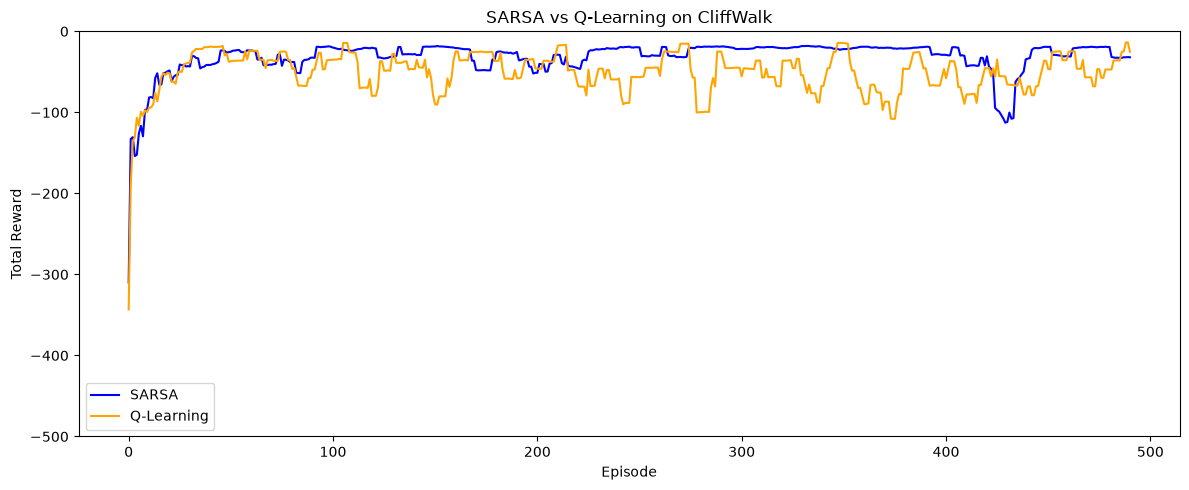

Last 50 episode avg:
  SARSA:      -24.1
  Q-Learning: -40.2
Note: Q-Learning learns optimal path (near cliff); SARSA learns safe path.


In [2]:
# ─── SARSA vs Q-Learning ───
def run_sarsa(env, n_episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1):
    Q = np.zeros((env.n_states, env.n_actions))
    episode_rewards = []

    for ep in range(n_episodes):
        s = env.reset()
        si = env.state_idx(s)
        # ε-greedy action
        a = np.random.randint(env.n_actions) if np.random.rand()<epsilon else np.argmax(Q[si])
        total_r = 0
        for _ in range(1000):
            s2, r, done = env.step(a)
            s2i = env.state_idx(s2)
            a2 = np.random.randint(env.n_actions) if np.random.rand()<epsilon else np.argmax(Q[s2i])
            # SARSA update
            Q[si,a] += alpha*(r + gamma*Q[s2i,a2] - Q[si,a])
            si, a = s2i, a2
            total_r += r
            if done: break
        episode_rewards.append(total_r)
    return Q, episode_rewards

def run_qlearning(env, n_episodes=500, alpha=0.5, gamma=1.0, epsilon=0.1):
    Q = np.zeros((env.n_states, env.n_actions))
    episode_rewards = []

    for ep in range(n_episodes):
        s = env.reset()
        total_r = 0
        for _ in range(1000):
            si = env.state_idx(s)
            a = np.random.randint(env.n_actions) if np.random.rand()<epsilon else np.argmax(Q[si])
            s2, r, done = env.step(a)
            s2i = env.state_idx(s2)
            # Q-Learning update
            Q[si,a] += alpha*(r + gamma*np.max(Q[s2i]) - Q[si,a])
            s = s2
            total_r += r
            if done: break
        episode_rewards.append(total_r)
    return Q, episode_rewards

sarsa_Q, sarsa_rewards   = run_sarsa(env)
ql_Q,    ql_rewards      = run_qlearning(env)

# Smooth and plot
def smooth(x, w=10): return np.convolve(x, np.ones(w)/w, mode='valid')

plt.figure(figsize=(12,5))
plt.plot(smooth(sarsa_rewards), label='SARSA', color='blue')
plt.plot(smooth(ql_rewards),    label='Q-Learning', color='orange')
plt.xlabel('Episode'); plt.ylabel('Total Reward')
plt.title('SARSA vs Q-Learning on CliffWalk')
plt.legend(); plt.ylim(-500, 0); plt.tight_layout(); plt.show()
print("Last 50 episode avg:")
print(f"  SARSA:      {np.mean(sarsa_rewards[-50:]):.1f}")
print(f"  Q-Learning: {np.mean(ql_rewards[-50:]):.1f}")
print("Note: Q-Learning learns optimal path (near cliff); SARSA learns safe path.")

## Additional Learning Resources

### Books
- **Sutton & Barto Ch. 5-7** (MC, TD, n-step): http://incompleteideas.net/book/the-book-2nd.html

### Courses
- **David Silver Lecture 4** Model-Free Prediction: https://www.davidsilver.uk/teaching/
- **David Silver Lecture 5** Model-Free Control
- **Hugging Face RL Course Unit 2**: https://huggingface.co/learn/deep-rl-course/unit2

### Papers
- **Q-Learning** (Watkins 1989): https://link.springer.com/article/10.1007/BF00992698
- **TD-Gammon** (Tesauro 1995): https://dl.acm.org/doi/10.1145/203330.203343

### Code
- **CliffWalk in Gymnasium**: https://gymnasium.farama.org/environments/toy_text/cliff_walking/